# HOMEWORK 13

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

C:\Users\Стас\AppData\Local\Temp\ipykernel_50920\4068296623.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


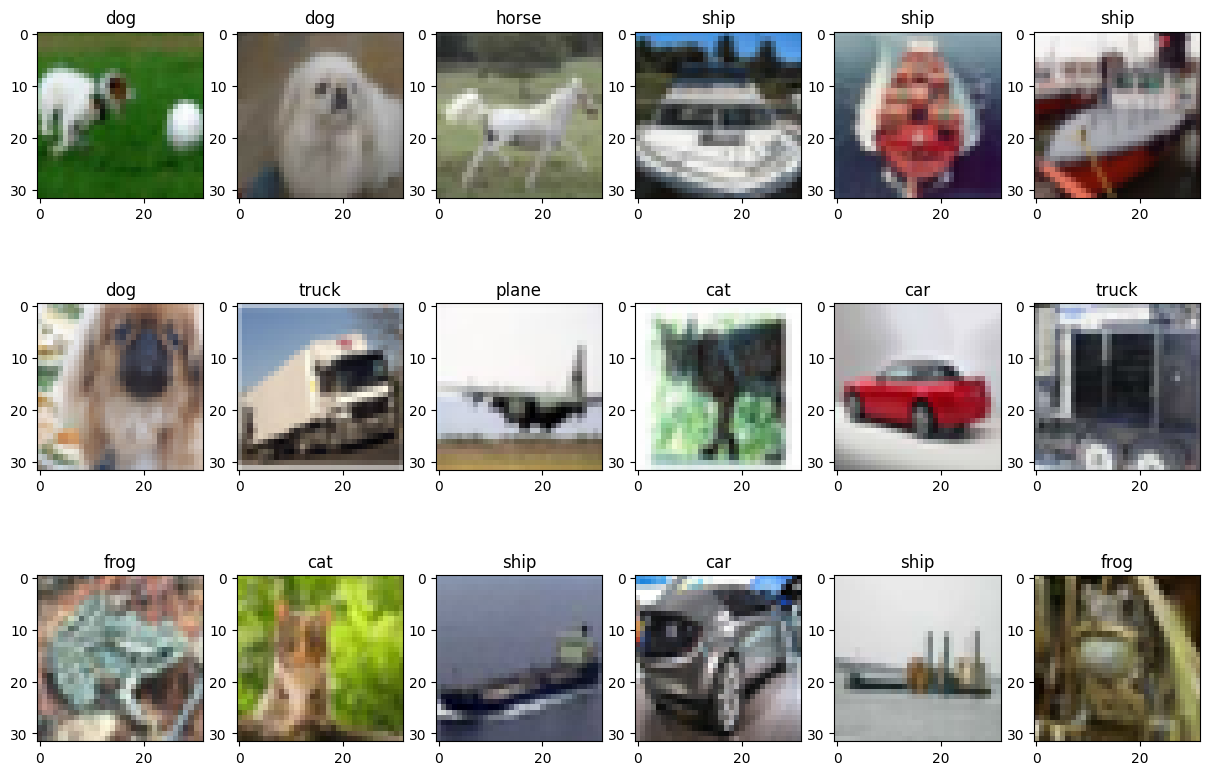

In [2]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, len(y_train))
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

In [3]:
pics = dict()
for i in range(0, len(y_train)):
    x = pics.get(classes[int(y_train[i])])
    if(x != None and x >= 1):
        pics.update({classes[int(y_train[i])]: x+1})
    else:   
        pics.update({classes[int(y_train[i])]: 1})

C:\Users\Стас\AppData\Local\Temp\ipykernel_50920\233220979.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = pics.get(classes[int(y_train[i])])
C:\Users\Стас\AppData\Local\Temp\ipykernel_50920\233220979.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pics.update({classes[int(y_train[i])]: 1})
C:\Users\Стас\AppData\Local\Temp\ipykernel_50920\233220979.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pics.update({classes[int(y_train[i])]: x+1})


In [4]:
from collections import Counter
x = y_train.tostring()
hist = Counter(x)

C:\Users\Стас\AppData\Local\Temp\ipykernel_50920\3269748668.py:2: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  x = y_train.tostring()


(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

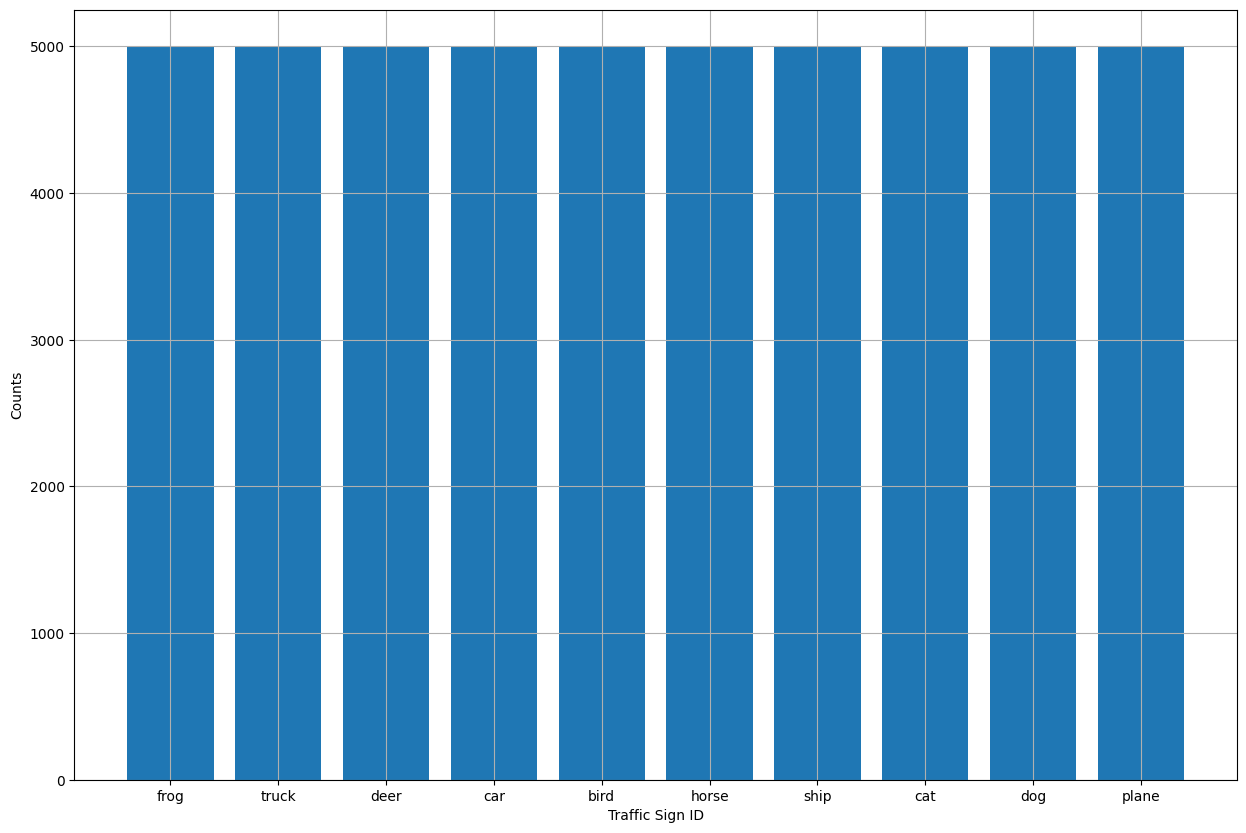

In [5]:
plt.bar(pics.keys(), pics.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [6]:
from tensorflow.keras.utils import to_categorical
# Normalization
x_train = x_train/255
x_test = x_test/255

# One-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [20]:
# Build the classifier
from tensorflow.keras.layers import  Dropout, BatchNormalization

inputs = Input(shape=(size, size, 3))
x = Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

# x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
# x = BatchNormalization()(x) # Додаємо стабілізацію
# x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
# x = MaxPooling2D(pool_size=(2, 2))(x)
# x = Dropout(0.2)(x) # 20% нейронів відпочивають

# # Блок 2
# x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
# x = BatchNormalization()(x)
# x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
# x = MaxPooling2D(pool_size=(2, 2))(x)
# x = Dropout(0.3)(x)

# # Класифікатор
# x = Flatten()(x)
# x = Dense(128, activation='relu')(x)
# x = Dropout(0.5)(x) # Більше регуляризації перед виходом
# outputs = Dense(10, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Show the model
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_8 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 flatten_3 (Flatten)         (None, 2304)              0   

### Step 3: Training

Compile the model and train it.

In [21]:
model.compile(loss="mse", optimizer="adam", metrics=["accuracy"])

In [22]:
epochs = 10
batch_size = 128

# Compile the model

# Train the model
history = model.fit(x_train, y_train, batch_size = batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/10
193/313 [=================>............] - ETA: 6s - loss: 0.0761 - accuracy: 0.3581

KeyboardInterrupt: 

Train Acc      0.7684249877929688
Validation Acc 0.6859999895095825


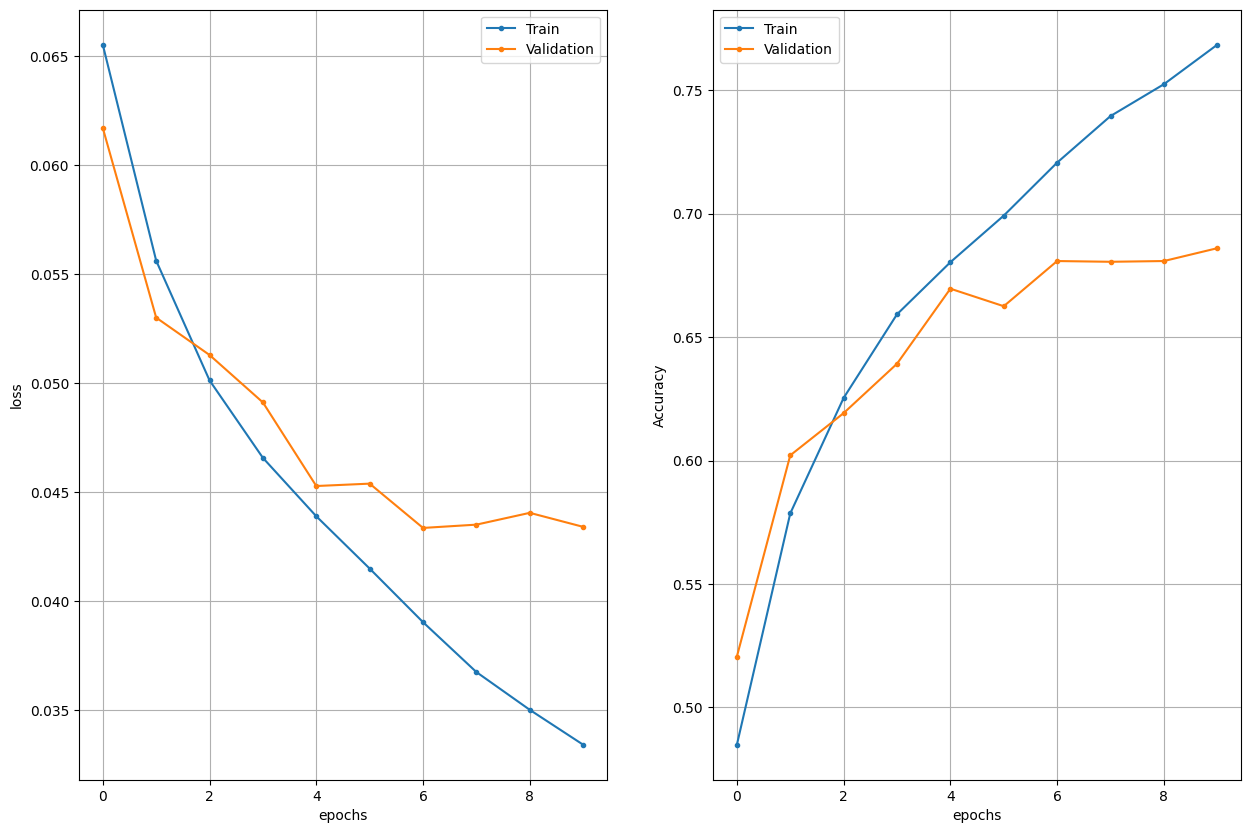

In [15]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [33]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1)

313/313 [==============================] - 2s 5ms/step


In [34]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    
    idx = (y_true == class_id)
    correct = np.sum(y_pred_labels[idx] == y_true[idx])
    total = np.sum(idx)
    
    acc = correct / total if total > 0 else 0
    print(class_name, acc)

plane 0.706
car 0.724
bird 0.593
cat 0.61
deer 0.66
dog 0.517
frog 0.683
horse 0.687
ship 0.804
truck 0.812


In [35]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 [==============================] - 2s 5ms/step - loss: 0.0501 - accuracy: 0.6796
Test loss   0.05014267936348915
Test metric 0.6796000003814697


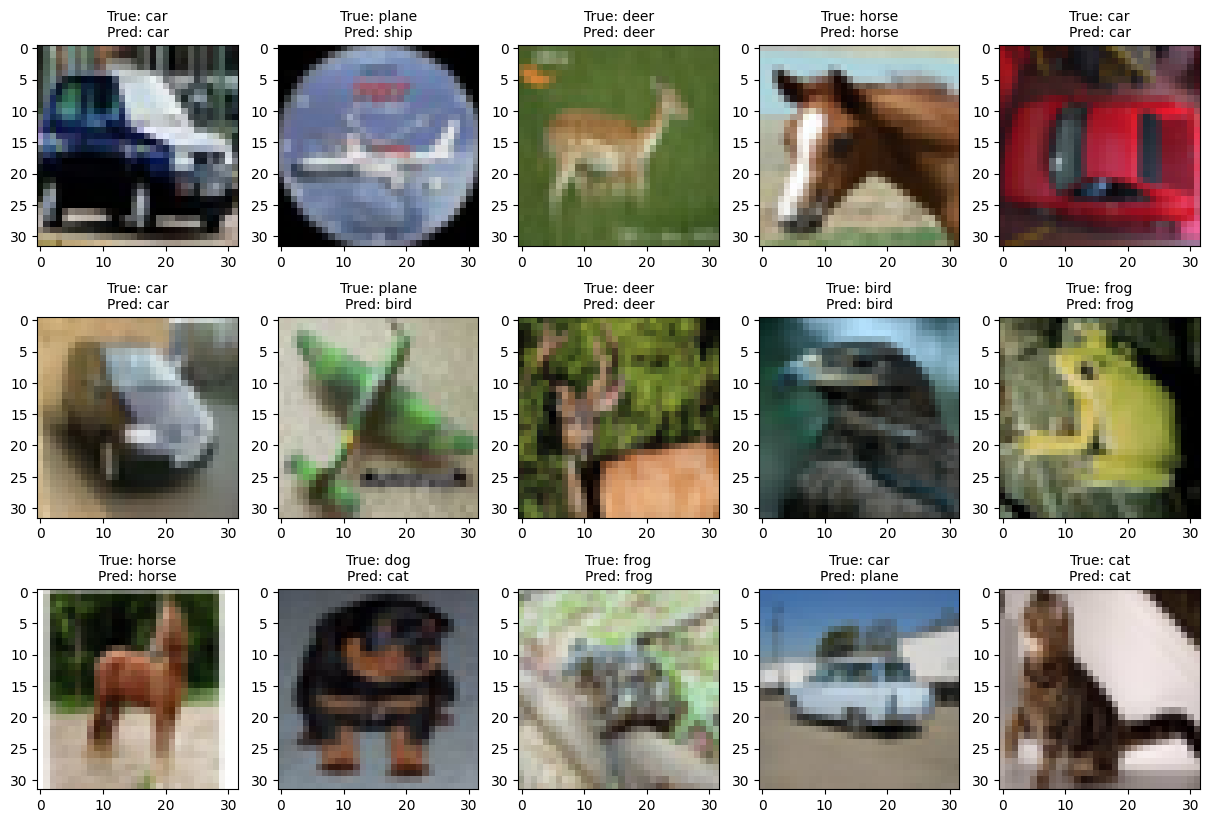

In [ ]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(y_test))
    # Show the results
    t_idx = y_true[idx]
    if isinstance(t_idx, np.ndarray): t_idx = np.argmax(t_idx)

    p_idx = y_pred[idx]
    if isinstance(p_idx, np.ndarray): p_idx = np.argmax(p_idx)

    plt.subplot(3, 5, ii + 1)
    plt.title(f"True: {classes[int(t_idx)]}\nPred: {classes[int(p_idx)]}", fontsize=10)
    plt.imshow(x_test[idx])

### Questions
* What is the overall accuracy of the classifier?
* What modifications would you do in order to improve the classification accuracy?
* Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?

##### 1. So, the accuracy for test dataset was 93% while for validation 68%, so more relevant in real work will be 68%
##### 2. I think that the best modification will be to add more hidden layers and dropout
##### 3. This approach allows to have almost 75% on validation dataset